In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Generalizable-DDA-RL

import os

os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

print("Current directory:", os.getcwd())

/content/drive/MyDrive/Generalizable-DDA-RL
Current directory: /content/drive/MyDrive/Generalizable-DDA-RL


### ***Imports***

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

print("Imports successful!")

Imports successful!


### ***Evaluation Results***

In [4]:
RESULTS_PATH = "results/evaluation_raw_results.csv"

results_df = pd.read_csv(RESULTS_PATH)

print("Here are the Results :)")
print("Shape:", results_df.shape)

results_df.head()

Here are the Results :)
Shape: (200, 14)


,Player Profile,Method,Seed,Win Rate Error,Difficulty Change Std,Mean Absolute Difficulty Change,Episode Length,Total Reward,Mean Reward,Mean Win Rate,Final Win Rate,Mean Difficulty,Final Difficulty,Mean Error Rate
0,Stable,Static Easy,0,0.178294,0.005541,0.001206,200,143.087161,0.715436,0.865627,1.0,0.206,0.2,0.000053
1,Stable,Static Easy,1,0.219710,0.005541,0.001206,200,110.760788,0.553804,0.898710,0.9,0.206,0.2,0.000000
2,Stable,Static Easy,2,0.198000,0.005541,0.001206,200,129.389630,0.646948,0.898000,0.9,0.206,0.2,0.000000
3,Stable,Static Easy,3,0.211319,0.005541,0.001206,200,120.738169,0.603691,0.910319,0.9,0.206,0.2,0.000154
4,Stable,Static Easy,4,0.209444,0.005541,0.001206,200,121.203887,0.606019,0.901444,0.9,0.206,0.2,0.000190


### ***Methods and Profiles***

In [5]:
print("Methods:")
print(results_df["Method"].unique())

print("\nPlayer Profiles:")
print(results_df["Player Profile"].unique())

print("\nSeeds:")
print(sorted(results_df["Seed"].unique()))

Methods:
['Static Easy' 'Static Medium' 'Static Hard' 'Rule-Based DDA' 'PPO DDA']

Player Profiles:
['Stable' 'Learning' 'Fatigue' 'Noisy']

Seeds:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


### ***Check Missing Values***

In [6]:
missing_values = results_df.isnull().sum()

missing_values[missing_values > 0]

,0


### ***Overall Descriptive Statistics***
This calculates mean ± standard deviation across all profiles and seeds

In [7]:
metrics = [
    "Win Rate Error",
    "Difficulty Change Std",
    "Mean Absolute Difficulty Change",
    "Total Reward",
    "Mean Win Rate",
    "Mean Difficulty",
    "Mean Error Rate"
]

overall_stats = (
    results_df
    .groupby("Method")[metrics]
    .agg(["mean", "std"])
)

overall_stats = overall_stats.round(4)

overall_stats

Win Rate Error         Difficulty Change Std          \
                         mean     std                  mean     std   
Method                                                                
PPO DDA                0.0855  0.0103                0.0688  0.0024   
Rule-Based DDA         0.1340  0.0176                0.0140  0.0005   
Static Easy            0.2303  0.0222                0.0055  0.0000   
Static Hard            0.5183  0.0611                0.0055  0.0000   
Static Medium          0.2045  0.0545                0.0000  0.0000   

               Mean Absolute Difficulty Change         Total Reward           \
                                          mean     std         mean      std   
Method                                                                         
PPO DDA                                 0.0576  0.0022     207.3371   9.1353   
Rule-Based DDA                          0.0123  0.0008     169.7896  15.2826   
Static Easy                             0.0012  0.0000     104.8669  17.0669   
Static Hard                             0.0012  0.0000    -283.8857  91.1188   
Static Medium                           0.0000  0.0000     106.6023  50.6272   

               Mean Win Rate         Mean Difficulty         Mean Error Rate  \
                        mean     std            mean     std            mean   
Method                                                                         
PPO DDA               0.7374  0.0142          0.4024  0.0365          0.0268   
Rule-Based DDA        0.6857  0.0121          0.4452  0.0433          0.0281   
Static Easy           0.9122  0.0272          0.2060  0.0000          0.0048   
Static Hard           0.1864  0.0624          0.7940  0.0000          0.2835   
Static Medium         0.5964  0.0726          0.5000  0.0000          0.0508   

                        
                   std  
Method                  
PPO DDA         0.0213  
Rule-Based DDA  0.0237  
Static Easy     0.0064  
Static Hard     0.0451  
Static Medium   0.0196

In [8]:
overall_stats.to_csv(
    "results/overall_statistics.csv"
)

print("Saved!")

Saved!


### ***Mean ± Std table***

In [9]:
clean_table = pd.DataFrame()

for metric in metrics:

    mean_values = (
        results_df
        .groupby("Method")[metric]
        .mean()
    )

    std_values = (
        results_df
        .groupby("Method")[metric]
        .std()
    )

    clean_table[metric] = (
        mean_values.round(4).astype(str)
        +
        " ± "
        +
        std_values.round(4).astype(str)
    )

clean_table

,Win Rate Error,Difficulty Change Std,Mean Absolute Difficulty Change,Total Reward,Mean Win Rate,Mean Difficulty,Mean Error Rate
Method,,,,,,,
PPO DDA,0.0855 ± 0.0103,0.0688 ± 0.0024,0.0576 ± 0.0022,207.3371 ± 9.1353,0.7374 ± 0.0142,0.4024 ± 0.0365,0.0268 ± 0.0213
Rule-Based DDA,0.134 ± 0.0176,0.014 ± 0.0005,0.0123 ± 0.0008,169.7896 ± 15.2826,0.6857 ± 0.0121,0.4452 ± 0.0433,0.0281 ± 0.0237
Static Easy,0.2303 ± 0.0222,0.0055 ± 0.0,0.0012 ± 0.0,104.8669 ± 17.0669,0.9122 ± 0.0272,0.206 ± 0.0,0.0048 ± 0.0064
Static Hard,0.5183 ± 0.0611,0.0055 ± 0.0,0.0012 ± 0.0,-283.8857 ± 91.1188,0.1864 ± 0.0624,0.794 ± 0.0,0.2835 ± 0.0451
Static Medium,0.2045 ± 0.0545,0.0 ± 0.0,0.0 ± 0.0,106.6023 ± 50.6272,0.5964 ± 0.0726,0.5 ± 0.0,0.0508 ± 0.0196


In [10]:
clean_table.to_csv(
    "results/mean_std_results.csv"
)

print("Mean ± Std Table Saved!")

Mean ± Std Table Saved!


### ***Results by Player Profile***

In [11]:
profile_stats = (
    results_df
    .groupby(
        ["Player Profile", "Method"]
    )[metrics]
    .agg(["mean", "std"])
    .round(4)
)

profile_stats

Win Rate Error         Difficulty Change Std  \
                                        mean     std                  mean   
Player Profile Method                                                        
Fatigue        PPO DDA                0.0882  0.0089                0.0702   
               Rule-Based DDA         0.1351  0.0193                0.0140   
               Static Easy            0.2474  0.0078                0.0055   
               Static Hard            0.4999  0.0293                0.0055   
               Static Medium          0.1964  0.0230                0.0000   
Learning       PPO DDA                0.0949  0.0068                0.0686   
               Rule-Based DDA         0.1468  0.0159                0.0141   
               Static Easy            0.2361  0.0220                0.0055   
               Static Hard            0.4783  0.0196                0.0055   
               Static Medium          0.2657  0.0168                0.0000   
Noisy          PPO DDA                0.0843  0.0049                0.0703   
               Rule-Based DDA         0.1254  0.0179                0.0137   
               Static Easy            0.2288  0.0198                0.0055   
               Static Hard            0.4829  0.0341                0.0055   
               Static Medium          0.1299  0.0160                0.0000   
Stable         PPO DDA                0.0745  0.0085                0.0662   
               Rule-Based DDA         0.1286  0.0101                0.0140   
               Static Easy            0.2089  0.0180                0.0055   
               Static Hard            0.6123  0.0198                0.0055   
               Static Medium          0.2261  0.0297                0.0000   

                                      Mean Absolute Difficulty Change          \
                                  std                            mean     std   
Player Profile Method                                                           
Fatigue        PPO DDA         0.0014                          0.0586  0.0015   
               Rule-Based DDA  0.0005                          0.0124  0.0009   
               Static Easy     0.0000                          0.0012  0.0000   
               Static Hard     0.0000                          0.0012  0.0000   
               Static Medium   0.0000                          0.0000  0.0000   
Learning       PPO DDA         0.0024                          0.0569  0.0025   
               Rule-Based DDA  0.0003                          0.0125  0.0006   
               Static Easy     0.0000                          0.0012  0.0000   
               Static Hard     0.0000                          0.0012  0.0000   
               Static Medium   0.0000                          0.0000  0.0000   
Noisy          PPO DDA         0.0015                          0.0590  0.0014   
               Rule-Based DDA  0.0006                          0.0118  0.0011   
               Static Easy     0.0000                          0.0012  0.0000   
               Static Hard     0.0000                          0.0012  0.0000   
               Static Medium   0.0000                          0.0000  0.0000   
Stable         PPO DDA         0.0020                          0.0559  0.0020   
               Rule-Based DDA  0.0003                          0.0123  0.0005   
               Static Easy     0.0000                          0.0012  0.0000   
               Static Hard     0.0000                          0.0012  0.0000   
               Static Medium   0.0000                          0.0000  0.0000   

                              Total Reward          Mean Win Rate          \
                                      mean      std          mean     std   
Player Profile Method                                                       
Fatigue        PPO DDA            206.5148   7.4205        0.7485  0.0064   
               Rule-Based DDA     170.3989  15.5461        0.67

In [12]:
profile_stats.to_csv(
    "results/profile_statistics.csv"
)

print("Saved!")

Saved!


### ***PPO vs Every Baseline***
Our Primary metrics is Win Rate Error

Lower is Better

In [13]:
ppo_error = (
    results_df[
        results_df["Method"] == "PPO DDA"
    ]
    .groupby("Seed")["Win Rate Error"]
    .mean()
)

comparison_methods = [
    "Static Easy",
    "Static Medium",
    "Static Hard",
    "Rule-Based DDA"
]

comparison_results = []

for method in comparison_methods:

    baseline_error = (
        results_df[
            results_df["Method"] == method
        ]
        .groupby("Seed")["Win Rate Error"]
        .mean()
    )

    common_seeds = (
        ppo_error.index
        .intersection(baseline_error.index)
    )

    ppo_values = (
        ppo_error
        .loc[common_seeds]
    )

    baseline_values = (
        baseline_error
        .loc[common_seeds]
    )

    ppo_mean = ppo_values.mean()
    baseline_mean = baseline_values.mean()

    improvement = (
        (
            baseline_mean
            -
            ppo_mean
        )
        /
        baseline_mean
        *
        100
    )

    comparison_results.append({

        "Baseline":
            method,

        "PPO Win Rate Error":
            ppo_mean,

        "Baseline Win Rate Error":
            baseline_mean,

        "PPO Improvement (%)":
            improvement

    })

comparison_df = pd.DataFrame(
    comparison_results
).round(4)

comparison_df

,Baseline,PPO Win Rate Error,Baseline Win Rate Error,PPO Improvement (%)
0,Static Easy,0.0855,0.2303,62.8808
1,Static Medium,0.0855,0.2045,58.2047
2,Static Hard,0.0855,0.5183,83.5076
3,Rule-Based DDA,0.0855,0.1340,36.1912


In [14]:
comparison_df.to_csv(
    "results/ppo_vs_baselines.csv",
    index=False
)

print("Saved :)")

Saved :)


### ***Paired Statistical Tests***
We use paired tests because the methods are evaluated using the same random seeds

In [15]:
test_results = []

for method in comparison_methods:

    baseline_error = (
        results_df[
            results_df["Method"] == method
        ]
        .groupby("Seed")["Win Rate Error"]
        .mean()
    )

    common_seeds = (
        ppo_error.index
        .intersection(
            baseline_error.index
        )
    )

    ppo_values = (
        ppo_error
        .loc[common_seeds]
    )

    baseline_values = (
        baseline_error
        .loc[common_seeds]
    )

    statistic, p_value = stats.ttest_rel(
        ppo_values,
        baseline_values
    )

    test_results.append({

        "Comparison":
            f"PPO DDA vs {method}",

        "Test":
            "Paired t-test",

        "Statistic":
            statistic,

        "P-value":
            p_value,

        "Significant (p < 0.05)":
            p_value < 0.05

    })


test_df = pd.DataFrame(
    test_results
).round(6)

test_df

,Comparison,Test,Statistic,P-value,Significant (p < 0.05)
0,PPO DDA vs Static Easy,Paired t-test,-30.289129,0.0,True
1,PPO DDA vs Static Medium,Paired t-test,-23.858106,0.0,True
2,PPO DDA vs Static Hard,Paired t-test,-67.965106,0.0,True
3,PPO DDA vs Rule-Based DDA,Paired t-test,-13.331080,0.0,True


In [16]:
test_df.to_csv(
    "results/statistical_tests.csv",
    index=False
)

print("Saved :)")

Saved :)


### ***Calculate Effect Size (Cohen's D)***

In [17]:
effect_results = []

for method in comparison_methods:

    baseline_error = (
        results_df[
            results_df["Method"] == method
        ]
        .groupby("Seed")["Win Rate Error"]
        .mean()
    )

    common_seeds = (
        ppo_error.index
        .intersection(
            baseline_error.index
        )
    )

    ppo_values = (
        ppo_error
        .loc[common_seeds]
    )

    baseline_values = (
        baseline_error
        .loc[common_seeds]
    )

    differences = (
        baseline_values
        -
        ppo_values
    )

    cohen_d = (
        differences.mean()
        /
        differences.std(ddof=1)
    )

    effect_results.append({

        "Comparison":
            f"PPO DDA vs {method}",

        "Cohen's d":
            cohen_d

    })


effect_df = pd.DataFrame(
    effect_results
).round(4)

effect_df

,Comparison,Cohen's d
0,PPO DDA vs Static Easy,9.5783
1,PPO DDA vs Static Medium,7.5446
2,PPO DDA vs Static Hard,21.4925
3,PPO DDA vs Rule-Based DDA,4.2157


In [18]:
effect_df.to_csv(
    "results/effect_sizes.csv",
    index=False
)

print("Effect Sizes")
print("Status : Saved :)")

Effect Sizes
Status : Saved :)


### ***Overall Win Rate Error with Standard Deviation***

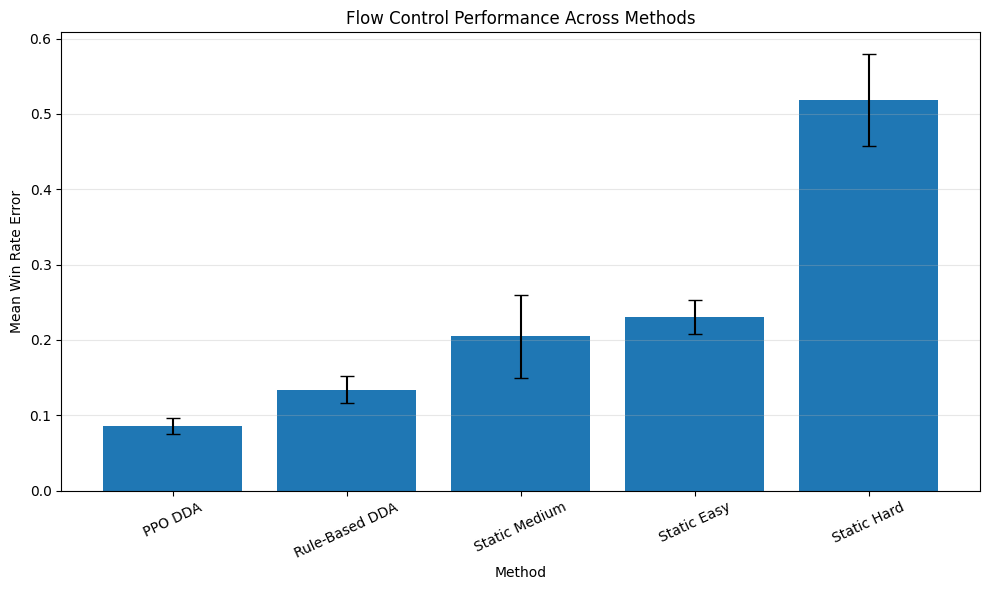

In [19]:
error_stats = (
    results_df
    .groupby("Method")["Win Rate Error"]
    .agg(["mean", "std"])
    .sort_values("mean")
)

plt.figure(figsize=(10, 6))

plt.bar(
    error_stats.index,
    error_stats["mean"],
    yerr=error_stats["std"],
    capsize=5
)

plt.xlabel("Method")
plt.ylabel("Mean Win Rate Error")

plt.title(
    "Flow Control Performance Across Methods"
)

plt.xticks(rotation=25)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "figures/statistical_win_rate_error.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### ***PPO Performance across Player Profiles***

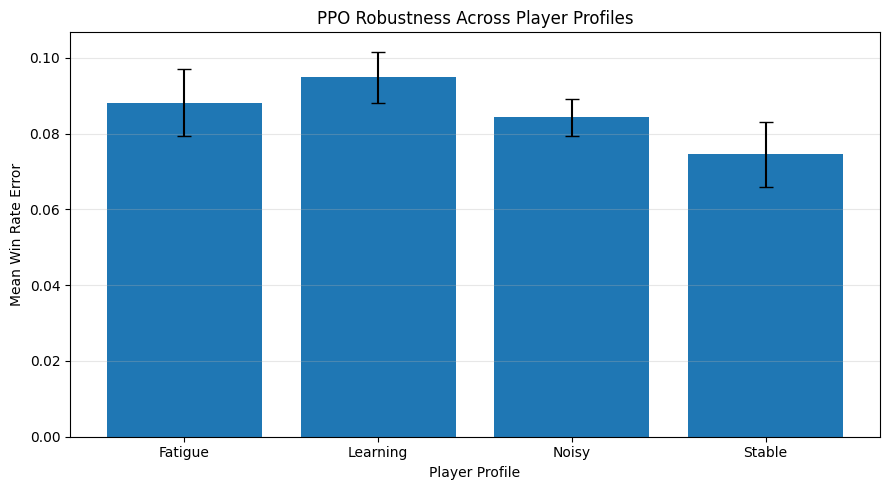

In [20]:
ppo_profile_stats = (
    results_df[
        results_df["Method"] == "PPO DDA"
    ]
    .groupby("Player Profile")[
        "Win Rate Error"
    ]
    .agg(["mean", "std"])
)

plt.figure(figsize=(9, 5))

plt.bar(
    ppo_profile_stats.index,
    ppo_profile_stats["mean"],
    yerr=ppo_profile_stats["std"],
    capsize=5
)

plt.xlabel("Player Profile")
plt.ylabel("Mean Win Rate Error")

plt.title(
    "PPO Robustness Across Player Profiles"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "figures/ppo_profile_robustness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### ***PPO vs Rule-Based DDA***

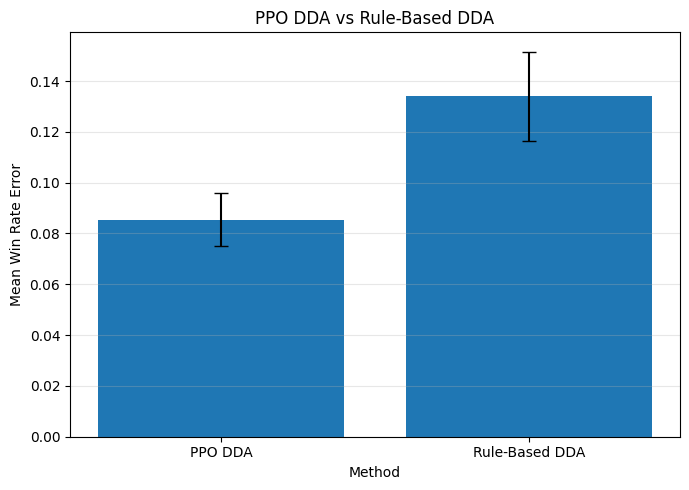

In [21]:
ppo_rule_data = results_df[
    results_df["Method"].isin(
        [
            "PPO DDA",
            "Rule-Based DDA"
        ]
    )
]

ppo_rule_stats = (
    ppo_rule_data
    .groupby(
        "Method"
    )[
        "Win Rate Error"
    ]
    .agg(
        ["mean", "std"]
    )
    .sort_values(
        "mean"
    )
)

plt.figure(figsize=(7, 5))

plt.bar(
    ppo_rule_stats.index,
    ppo_rule_stats["mean"],
    yerr=ppo_rule_stats["std"],
    capsize=5
)

plt.xlabel("Method")
plt.ylabel("Mean Win Rate Error")

plt.title(
    "PPO DDA vs Rule-Based DDA"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "figures/ppo_vs_rule_based.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### ***Final Ranking***

In [22]:
final_ranking = (
    results_df
    .groupby("Method")
    .agg(

        Mean_Win_Rate_Error=(
            "Win Rate Error",
            "mean"
        ),

        Std_Win_Rate_Error=(
            "Win Rate Error",
            "std"
        ),

        Mean_Total_Reward=(
            "Total Reward",
            "mean"
        ),

        Mean_Difficulty_Change_Std=(
            "Difficulty Change Std",
            "mean"
        )

    )
    .sort_values(
        "Mean_Win_Rate_Error"
    )
    .round(4)
)

final_ranking

,Mean_Win_Rate_Error,Std_Win_Rate_Error,Mean_Total_Reward,Mean_Difficulty_Change_Std
Method,,,,
PPO DDA,0.0855,0.0103,207.3371,0.0688
Rule-Based DDA,0.1340,0.0176,169.7896,0.0140
Static Medium,0.2045,0.0545,106.6023,0.0000
Static Easy,0.2303,0.0222,104.8669,0.0055
Static Hard,0.5183,0.0611,-283.8857,0.0055


In [23]:
final_ranking.to_csv(
    "results/final_method_ranking.csv"
)

print("Saved")

Saved


### ***Conclusion***
Preliminary Interpretation based on the Primary Metric.

In [24]:
best_method = (
    final_ranking
    .index[0]
)

best_error = (
    final_ranking
    .iloc[0][
        "Mean_Win_Rate_Error"
    ]
)

print(
    "PRIMARY RESULT"
)

print(
    "-" * 40
)

print(
    f"Best method: {best_method}"
)

print(
    f"Mean Win Rate Error: {best_error:.4f}"
)

print()

if best_method == "PPO DDA":

    print(
        "PPO DDA achieved the Lowest Average Win-Rate Error in this Evaluation"
    )

else:

    print(
        f"{best_method} Achieved the Lowest Average Win-Rate Error in this Evaluation"
    )

    print(
        "Do not claim PPO outperformed all baselines unless the results support that conclusion"
    )

PRIMARY RESULT
----------------------------------------
Best method: PPO DDA
Mean Win Rate Error: 0.0855

PPO DDA achieved the Lowest Average Win-Rate Error in this Evaluation


### ***Final Results Check***

In [25]:
print("RESULTS FILES")
print("=" * 40)

!ls -lh results/

print("\nFIGURE FILES")
print("=" * 40)

!ls -lh figures/

RESULTS FILES
total 66K
-rw------- 1 root root  147 Sep 11 16:56 effect_sizes.csv
-rw------- 1 root root  38K Sep  8 18:37 evaluation_raw_results.csv
-rw------- 1 root root 3.2K Sep  8 18:39 evaluation_summary.csv
drwx------ 2 root root 4.0K Sep  7 14:26 figures
-rw------- 1 root root  298 Sep 11 16:56 final_method_ranking.csv
-rw------- 1 root root  766 Sep 11 16:56 mean_std_results.csv
-rw------- 1 root root  868 Sep 11 16:56 overall_statistics.csv
-rw------- 1 root root  212 Sep 11 16:56 ppo_vs_baselines.csv
-rw------- 1 root root 2.6K Sep 11 16:56 profile_statistics.csv
-rw------- 1 root root  289 Sep 11 16:56 statistical_tests.csv
-rw------- 1 root root  487 Sep 10 15:38 Table_1_Main_Results.csv
-rw------- 1 root root  359 Sep 10 15:39 Table_2_PPO_vs_Baselines.csv
-rw------- 1 root root  328 Sep 10 15:41 Table_3_Statistical_Results.csv
drwx------ 2 root root 4.0K Sep  7 14:26 tables
drwx------ 2 root root 4.0K Sep  8 09:15 training
drwx------ 2 root root 4.0K Sep  7 14:26 trajecto